# Retail Demand Forecasting & Inventory Optimization

Dataset: [Retail Store Inventory Forecasting Dataset](https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset)
synthetic daily data for multiple stores/products, with sales, inventory, pricing, promos,
weather, and holidays.

Goal: forecast daily `Units Sold` per store-product, then use that forecast to flag stockout risk
and recommend reorder quantities.

A couple of notes on setup before diving in:

- The dataset has a `Demand Forecast` column that looks like it could be used as a feature or even
  the target. I'm not using it that's someone else's forecast, and training on it (or against it)
  would just be learning to imitate another model, not learning from the actual sales data. Target
  is `Units Sold`.
- Price, discount, promotion, holiday, and weather are all treated as known ahead of time for a
  given day, since in practice retailers set these in advance and weather forecasts exist. Only
  `Units Sold` itself gets lagged into `lag_*`/`rolling_*` features, so no row sees its own future.


## Environment setup


In [1]:
import importlib
import subprocess
import sys


def _ensure(module_name, pip_name=None):
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name])


for _mod, _pip in [("kagglehub", "kagglehub"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm")]:
    _ensure(_mod, _pip)

print("Dependencies OK.")


Dependencies OK.


In [2]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)


## Load the data





In [3]:
DATA_PATH = None

_local_candidates = glob.glob("*.csv")
_local_candidates = [f for f in _local_candidates if "retail" in f.lower() or "inventory" in f.lower() or "demand" in f.lower()]
if _local_candidates:
    DATA_PATH = _local_candidates[0]

if DATA_PATH is None:
    try:
        import kagglehub

        dataset_dir = kagglehub.dataset_download("anirudhchauhan/retail-store-inventory-forecasting-dataset")
        csv_files = glob.glob(os.path.join(dataset_dir, "**", "*.csv"), recursive=True)
        if not csv_files:
            raise FileNotFoundError(f"No CSV found under {dataset_dir}")
        DATA_PATH = csv_files[0]
        print(f"Downloaded via kagglehub to: {DATA_PATH}")
    except Exception as e:
        print("kagglehub download unavailable or failed:", e)
        try:
            from google.colab import files

            print("Please upload the dataset CSV (downloaded from the Kaggle dataset page)...")
            uploaded = files.upload()
            DATA_PATH = next(iter(uploaded.keys()))
        except ImportError:
            raise FileNotFoundError(
                "Dataset CSV not found. Download it from "
                "https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset "
                "and place it in the working directory, or run this notebook in Colab."
            )

df_raw = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df_raw.shape)
print("\nColumns found in this file:")
print(list(df_raw.columns))
df_raw.head()


100%|██████████| 1.51M/1.51M [00:00<00:00, 31.7MB/s]

Extracting files...


Downloaded via kagglehub to: /root/.cache/kagglehub/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/versions/1/retail_store_inventory.csv
Loaded: /root/.cache/kagglehub/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/versions/1/retail_store_inventory.csv
Shape: (73100, 15)

Columns found in this file:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Resolve column names


In [4]:
COLUMN_CANDIDATES = {
    "date": ["Date", "date", "order_date"],
    "store": ["Store ID", "StoreID", "Store", "store_id"],
    "product": ["Product ID", "ProductID", "Product", "product_id", "SKU", "Item ID"],
    "category": ["Category", "category", "Product Category"],
    "region": ["Region", "region", "Store Region"],
    "inventory": ["Inventory Level", "InventoryLevel", "Inventory", "inventory_level"],
    "units_sold": ["Units Sold", "UnitsSold", "units_sold", "Sales", "Sales Quantity"],
    "units_ordered": ["Units Ordered", "UnitsOrdered", "units_ordered"],
    "price": ["Price", "price", "Unit Price"],
    "discount": ["Discount", "discount", "Discount (%)"],
    "weather": ["Weather Condition", "WeatherCondition", "Weather", "weather_condition"],
    "holiday": ["Holiday", "IsHoliday", "Holiday/Promotion", "holiday"],
    "promotion": ["Promotion", "Promotion Applied", "IsPromotion", "Holiday/Promotion", "promotion"],
    "competitor_price": ["Competitor Pricing", "CompetitorPricing", "Competitor Price", "competitor_pricing"],
    "seasonality": ["Seasonality", "seasonality", "Season"],
    "demand_forecast": ["Demand Forecast", "DemandForecast", "Demand", "demand_forecast"],
}

REQUIRED = {"date", "store", "product", "units_sold"}


def resolve_column(df, candidates, required, label):
    for c in candidates:
        if c in df.columns:
            return c
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for c in candidates:
        hit = lower_map.get(c.strip().lower())
        if hit is not None:
            return hit
    if required:
        raise KeyError(
            f"Could not find a column for '{label}'. Tried {candidates}. "
            f"Available columns: {list(df.columns)}. "
            f"Add the real column name to COLUMN_CANDIDATES['{label}'] above and rerun."
        )
    return None


COLS = {
    key: resolve_column(df_raw, candidates, key in REQUIRED, key)
    for key, candidates in COLUMN_CANDIDATES.items()
}

print("Resolved columns:")
for k, v in COLS.items():
    print(f"  {k:18s} -> {v}")


Resolved columns:
  date               -> Date
  store              -> Store ID
  product            -> Product ID
  category           -> Category
  region             -> Region
  inventory          -> Inventory Level
  units_sold         -> Units Sold
  units_ordered      -> Units Ordered
  price              -> Price
  discount           -> Discount
  weather            -> Weather Condition
  holiday            -> Holiday/Promotion
  promotion          -> Holiday/Promotion
  competitor_price   -> Competitor Pricing
  seasonality        -> Seasonality
  demand_forecast    -> Demand Forecast


## Clean and inspect


In [5]:
df = df_raw.copy()
df[COLS["date"]] = pd.to_datetime(df[COLS["date"]])
df = df.sort_values([COLS["store"], COLS["product"], COLS["date"]]).reset_index(drop=True)

print("Date range:", df[COLS["date"]].min().date(), "to", df[COLS["date"]].max().date())
print("Unique stores:", df[COLS["store"]].nunique())
print("Unique products:", df[COLS["product"]].nunique())
print("Rows:", len(df))
print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

n_dupes = df.duplicated(subset=[COLS["store"], COLS["product"], COLS["date"]]).sum()
print(f"\nDuplicate (store, product, date) rows: {n_dupes}")
if n_dupes:
    df = df.drop_duplicates(subset=[COLS["store"], COLS["product"], COLS["date"]], keep="first").reset_index(drop=True)
    print(f"Dropped duplicates -> {len(df)} rows remain")


def to_binary(series):
    if series.dtype == object:
        mapped = series.astype(str).str.strip().str.lower().map(
            {"yes": 1, "y": 1, "true": 1, "1": 1, "no": 0, "n": 0, "false": 0, "0": 0}
        )
        return mapped.fillna(0).astype(int)
    return series.fillna(0).astype(int)


if COLS["holiday"] is not None:
    df[COLS["holiday"]] = to_binary(df[COLS["holiday"]])
if COLS["promotion"] is not None and COLS["promotion"] != COLS["holiday"]:
    df[COLS["promotion"]] = to_binary(df[COLS["promotion"]])

df[COLS["units_sold"]] = df[COLS["units_sold"]].fillna(0)

df.head()


Date range: 2022-01-01 to 2024-01-01
Unique stores: 5
Unique products: 20
Rows: 73100

Missing values per column:
 Series([], dtype: int64)

Duplicate (store, product, date) rows: 0


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter


## Exploratory analysis


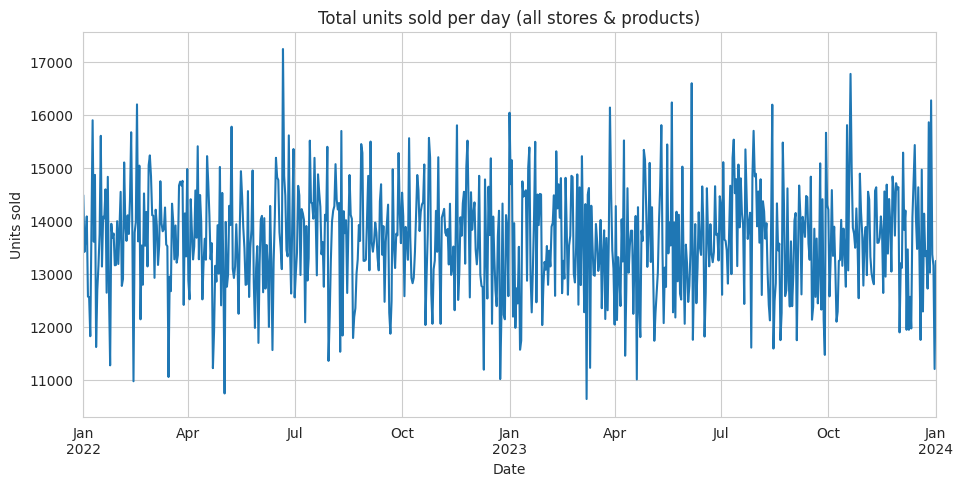

In [6]:
daily_total = df.groupby(COLS["date"])[COLS["units_sold"]].sum()

plt.figure()
daily_total.plot()
plt.title("Total units sold per day (all stores & products)")
plt.ylabel("Units sold")
plt.show()


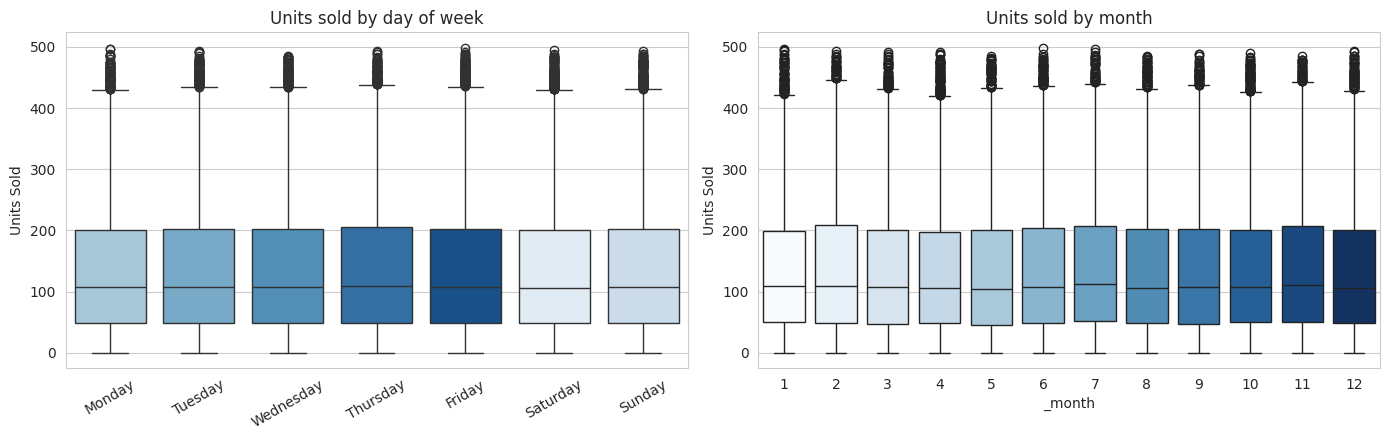

In [7]:
df["_dow"] = df[COLS["date"]].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="_dow", y=COLS["units_sold"], order=dow_order, ax=axes[0], hue="_dow",
            palette="Blues", legend=False)
axes[0].set_title("Units sold by day of week")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

df["_month"] = df[COLS["date"]].dt.month
sns.boxplot(data=df, x="_month", y=COLS["units_sold"], ax=axes[1], hue="_month", palette="Blues",
            legend=False)
axes[1].set_title("Units sold by month")
plt.tight_layout()
plt.show()


In [8]:
if COLS["holiday"] is not None:
    holiday_effect = df.groupby(COLS["holiday"])[COLS["units_sold"]].mean()
    print("Mean units sold, holiday vs. non-holiday:")
    print(holiday_effect)
else:
    print("No holiday column resolved — skipping.")

if COLS["promotion"] is not None:
    promo_effect = df.groupby(COLS["promotion"])[COLS["units_sold"]].mean()
    print("\nMean units sold, promotion on vs. off:")
    print(promo_effect)
else:
    print("No promotion column resolved — skipping.")


Mean units sold, holiday vs. non-holiday:
Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

Mean units sold, promotion on vs. off:
Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64


Top 10 products by total volume:
                  mean         std     sum        cv
Product ID                                          
P0016       139.116826  109.389823  508472  0.786316
P0020       138.907798  110.229782  507708  0.793546
P0014       138.884268  110.203837  507622  0.793494
P0015       138.791518  109.914956  507283  0.791943
P0005       137.796990  106.854998  503648  0.775452
P0009       137.369631  110.560806  502086  0.804842
P0013       136.968263  108.149168  500619  0.789593
P0017       136.938440  107.890733  500510  0.787878
P0011       136.624350  108.245989  499362  0.792289
P0007       136.613133  110.505351  499321  0.808893

Top 10 most volatile products (coefficient of variation):
                  mean         std     sum        cv
Product ID                                          
P0008       133.669767  108.675121  488563  0.813012
P0007       136.613133  110.505351  499321  0.808893
P0010       135.832832  109.721355  496469  0.807768
P0004  

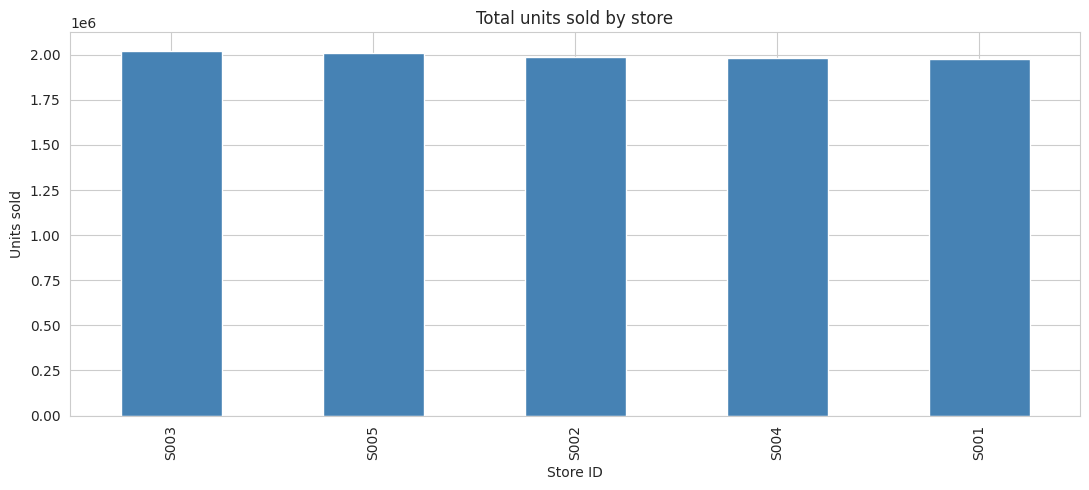

In [9]:
product_stats = df.groupby(COLS["product"])[COLS["units_sold"]].agg(["mean", "std", "sum"])
product_stats["cv"] = product_stats["std"] / product_stats["mean"].replace(0, np.nan)

print("Top 10 products by total volume:")
print(product_stats.sort_values("sum", ascending=False).head(10))

print("\nTop 10 most volatile products (coefficient of variation):")
print(product_stats.sort_values("cv", ascending=False).head(10))

store_stats = df.groupby(COLS["store"])[COLS["units_sold"]].sum().sort_values(ascending=False)
plt.figure()
store_stats.plot(kind="bar", color="steelblue")
plt.title("Total units sold by store")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()


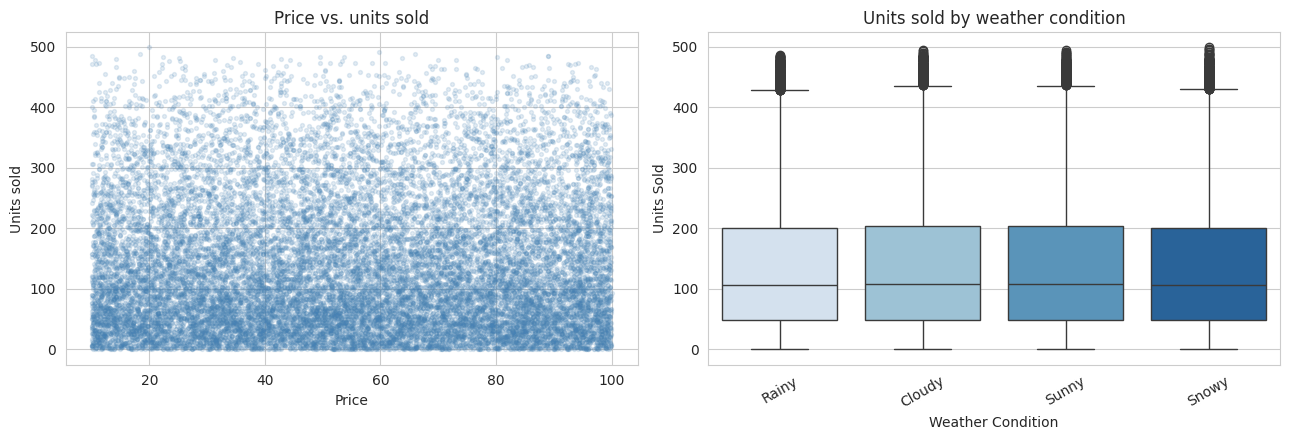

Correlation (price vs. units sold): 0.0011
Correlation (discount vs. units sold): 0.0026


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sample = df.sample(min(20000, len(df)), random_state=RANDOM_STATE)
axes[0].scatter(sample[COLS["price"]], sample[COLS["units_sold"]], alpha=0.15, s=8, color="steelblue")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Units sold")
axes[0].set_title("Price vs. units sold")

if COLS["weather"] is not None:
    sns.boxplot(data=df, x=COLS["weather"], y=COLS["units_sold"], ax=axes[1], hue=COLS["weather"],
                palette="Blues", legend=False)
    axes[1].set_title("Units sold by weather condition")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Correlation (price vs. units sold):", df[COLS["price"]].corr(df[COLS["units_sold"]]).round(4))
if COLS["discount"] is not None:
    print("Correlation (discount vs. units sold):", df[COLS["discount"]].corr(df[COLS["units_sold"]]).round(4))


## Chronological train / validation / test split


In [11]:
dates_sorted = np.sort(df[COLS["date"]].unique())
n_dates = len(dates_sorted)
train_end = dates_sorted[int(n_dates * 0.70)]
val_end = dates_sorted[int(n_dates * 0.85)]

print(f"Train:      {dates_sorted[0]} -> {train_end}")
print(f"Validation: {train_end} -> {val_end}")
print(f"Test:       {val_end} -> {dates_sorted[-1]}")


Train:      2022-01-01T00:00:00.000000000 -> 2023-05-27T00:00:00.000000000
Validation: 2023-05-27T00:00:00.000000000 -> 2023-09-14T00:00:00.000000000
Test:       2023-09-14T00:00:00.000000000 -> 2024-01-01T00:00:00.000000000


## Feature engineering

In [12]:
feat = df.copy()

# --- calendar features (safe: known in advance for any date) ---
feat["dow"] = feat[COLS["date"]].dt.dayofweek
feat["is_weekend"] = feat["dow"].isin([5, 6]).astype(int)
feat["month"] = feat[COLS["date"]].dt.month
feat["quarter"] = feat[COLS["date"]].dt.quarter
feat["week_of_year"] = feat[COLS["date"]].dt.isocalendar().week.astype(int)

# --- lag & rolling features of the TARGET, per store-product series ---
group_key = [COLS["store"], COLS["product"]]
g = feat.groupby(group_key)[COLS["units_sold"]]

LAGS = [1, 7, 14, 28]
for lag in LAGS:
    feat[f"lag_{lag}"] = g.shift(lag)

# shift(1) before rolling so the current day's own value never leaks into its own rolling stats
shifted_series = feat.groupby(group_key)[COLS["units_sold"]].shift(1)
feat["_shifted_target"] = shifted_series
for window in [7, 14, 28]:
    feat[f"rolling_mean_{window}"] = feat.groupby(group_key)["_shifted_target"].transform(
        lambda s: s.rolling(window, min_periods=max(2, window // 2)).mean()
    )
for window in [7, 28]:
    feat[f"rolling_std_{window}"] = feat.groupby(group_key)["_shifted_target"].transform(
        lambda s: s.rolling(window, min_periods=max(2, window // 2)).std()
    )
feat = feat.drop(columns=["_shifted_target"])

# --- lagged Inventory Level (see Section 8: same-day inventory can't be used as a feature) ---
if COLS["inventory"] is not None:
    feat["inventory_lag_1"] = feat.groupby(group_key)[COLS["inventory"]].shift(1)

# --- interaction features ---
if COLS["discount"] is not None and COLS["promotion"] is not None:
    feat["discount_x_promotion"] = feat[COLS["discount"]] * feat[COLS["promotion"]]
if COLS["price"] is not None and COLS["promotion"] is not None:
    feat["price_x_promotion"] = feat[COLS["price"]] * feat[COLS["promotion"]]
if COLS["price"] is not None and COLS["competitor_price"] is not None:
    feat["price_vs_competitor"] = feat[COLS["price"]] - feat[COLS["competitor_price"]]

n_before = len(feat)
feat = feat.dropna(subset=[f"lag_{max(LAGS)}"]).reset_index(drop=True)
print(f"Dropped {n_before - len(feat)} rows with insufficient history for the longest lag ({max(LAGS)} days)")
print("Feature columns added:", [c for c in feat.columns if c not in df.columns])


Dropped 2800 rows with insufficient history for the longest lag (28 days)
Feature columns added: ['dow', 'is_weekend', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'inventory_lag_1', 'discount_x_promotion', 'price_x_promotion', 'price_vs_competitor']


## Assemble the train / validation / test tables


In [13]:
ID_COLS = [COLS["store"], COLS["product"]]
NOMINAL_COLS = [c for c in [COLS["category"], COLS["region"], COLS["weather"], COLS["seasonality"]] if c is not None]
RAW_NUMERIC = [c for c in [COLS["price"], COLS["discount"], COLS["competitor_price"], COLS["inventory"],
                           COLS["holiday"], COLS["promotion"]] if c is not None]
# de-duplicate in case holiday/promotion resolved to the same underlying column
RAW_NUMERIC = list(dict.fromkeys(RAW_NUMERIC))

ENGINEERED_NUMERIC = [c for c in feat.columns if c.startswith(("lag_", "rolling_mean_", "rolling_std_"))]
ENGINEERED_NUMERIC += [c for c in ["discount_x_promotion", "price_x_promotion", "price_vs_competitor"] if c in feat.columns]
CALENDAR_NUMERIC = ["dow", "is_weekend", "month", "quarter", "week_of_year"]

NUMERIC_COLS = list(dict.fromkeys(RAW_NUMERIC + ENGINEERED_NUMERIC + CALENDAR_NUMERIC))
FEATURE_COLS = ID_COLS + NOMINAL_COLS + NUMERIC_COLS
TARGET_COL = COLS["units_sold"]

print(f"{len(FEATURE_COLS)} feature columns:")
print(FEATURE_COLS)

train_mask = feat[COLS["date"]] <= train_end
val_mask = (feat[COLS["date"]] > train_end) & (feat[COLS["date"]] <= val_end)
test_mask = feat[COLS["date"]] > val_end

X_train, y_train = feat.loc[train_mask, FEATURE_COLS], feat.loc[train_mask, TARGET_COL]
X_val, y_val = feat.loc[val_mask, FEATURE_COLS], feat.loc[val_mask, TARGET_COL]
X_test, y_test = feat.loc[test_mask, FEATURE_COLS], feat.loc[test_mask, TARGET_COL]

for name, Xs in [("Train", X_train), ("Val", X_val), ("Test", X_test)]:
    print(f"{name}: {Xs.shape}")


28 feature columns:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality', 'Price', 'Discount', 'Competitor Pricing', 'Inventory Level', 'Holiday/Promotion', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'discount_x_promotion', 'price_x_promotion', 'price_vs_competitor', 'dow', 'is_weekend', 'month', 'quarter', 'week_of_year']
Train: (48400, 28)
Val: (11000, 28)
Test: (10900, 28)


## Checking Inventory Level for a look-ahead problem



In [14]:
if COLS["inventory"] is not None:
    same_day_corr = feat[COLS["inventory"]].corr(feat[TARGET_COL])
    print(f"Correlation, same-day Inventory Level vs. Units Sold: {same_day_corr:.4f}")

    def _diagnostic_pipeline(numeric_cols):
        prep = ColumnTransformer(
            transformers=[
                ("nominal", OneHotEncoder(handle_unknown="ignore"), NOMINAL_COLS),
                ("ids", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ID_COLS),
                ("numeric", StandardScaler(), numeric_cols),
            ],
            remainder="drop",
        )
        return Pipeline([("preprocess", prep), ("model", LinearRegression())])

    variants = {
        "same-day Inventory Level (look-ahead)": NUMERIC_COLS,
        "Inventory Level dropped entirely": [c for c in NUMERIC_COLS if c != COLS["inventory"]],
        "yesterday's Inventory Level (inventory_lag_1)": [
            c if c != COLS["inventory"] else "inventory_lag_1" for c in NUMERIC_COLS
        ],
    }

    print()
    for label, num_cols in variants.items():
        cols_needed = ID_COLS + NOMINAL_COLS + num_cols
        pipe = _diagnostic_pipeline(num_cols)
        pipe.fit(feat.loc[train_mask, cols_needed], feat.loc[train_mask, TARGET_COL])
        pred = pipe.predict(feat.loc[val_mask, cols_needed])
        mae = mean_absolute_error(feat.loc[val_mask, TARGET_COL], pred)
        print(f"{label:45s} Validation MAE = {mae:.3f}")

    # Decision: switch to yesterday's value regardless of how close these numbers come out — same-day
    # Inventory Level is not obtainable at prediction time in a real deployment, so it is not a valid
    # feature even where it happens to correlate strongly with today's sales.
    NUMERIC_COLS = [c if c != COLS["inventory"] else "inventory_lag_1" for c in NUMERIC_COLS]
    FEATURE_COLS = ID_COLS + NOMINAL_COLS + NUMERIC_COLS

    X_train, y_train = feat.loc[train_mask, FEATURE_COLS], feat.loc[train_mask, TARGET_COL]
    X_val, y_val = feat.loc[val_mask, FEATURE_COLS], feat.loc[val_mask, TARGET_COL]
    X_test, y_test = feat.loc[test_mask, FEATURE_COLS], feat.loc[test_mask, TARGET_COL]

    print("\nSwitched to yesterday's Inventory Level. Every section below uses this corrected feature set.")
    for name, Xs in [("Train", X_train), ("Val", X_val), ("Test", X_test)]:
        print(f"{name}: {Xs.shape}")
else:
    print("No inventory column resolved — nothing to check.")


Correlation, same-day Inventory Level vs. Units Sold: 0.5899

same-day Inventory Level (look-ahead)         Validation MAE = 68.784
Inventory Level dropped entirely              Validation MAE = 89.847
yesterday's Inventory Level (inventory_lag_1) Validation MAE = 89.849

Switched to yesterday's Inventory Level. Every section below uses this corrected feature set.
Train: (48400, 28)
Val: (11000, 28)
Test: (10900, 28)


## Preprocessing pipeline


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore"), NOMINAL_COLS),
        ("ids", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ID_COLS),
        ("numeric", StandardScaler(), NUMERIC_COLS),
    ],
    remainder="drop",
)


## Evaluation metrics


In [16]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan


def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    w = wape(y_true, y_pred)
    print(f"{label:32s} MAE={mae:8.3f}  RMSE={rmse:8.3f}  WAPE={w:6.3%}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "WAPE": w}


## Naive and moving-average baselines


In [17]:
results = []
results.append(evaluate(y_val, X_val["lag_1"], "Naive (lag_1)"))
results.append(evaluate(y_val, X_val["rolling_mean_7"], "Moving average (7-day)"))


Naive (lag_1)                    MAE= 121.835  RMSE= 156.250  WAPE=89.064%
Moving average (7-day)           MAE=  94.526  RMSE= 117.414  WAPE=69.101%


## Model progression


In [18]:
tscv = TimeSeriesSplit(n_splits=5)

lr_pipe = Pipeline([("preprocess", preprocessor), ("model", LinearRegression())])
lr_pipe.fit(X_train, y_train)
results.append(evaluate(y_val, lr_pipe.predict(X_val), "Linear Regression"))


Linear Regression                MAE=  89.849  RMSE= 109.848  WAPE=65.682%


In [19]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
])
rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [6, 10, 16, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=12, scoring="neg_mean_absolute_error",
    cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
results.append(evaluate(y_val, rf_search.best_estimator_.predict(X_val), "Random Forest (tuned)"))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF params: {'model__n_estimators': 200, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 6}
Random Forest (tuned)            MAE=  89.896  RMSE= 109.843  WAPE=65.716%


In [20]:
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb.XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=1, tree_method="hist")),
])
xgb_param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
}
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=12, scoring="neg_mean_absolute_error",
    cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
results.append(evaluate(y_val, xgb_search.best_estimator_.predict(X_val), "XGBoost (tuned)"))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best XGB params: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
XGBoost (tuned)                  MAE=  89.902  RMSE= 109.839  WAPE=65.721%


In [21]:
lgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1)),
])
lgb_param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__num_leaves": [15, 31, 63],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
}
lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_param_dist, n_iter=12, scoring="neg_mean_absolute_error",
    cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
lgb_search.fit(X_train, y_train)
print("Best LightGBM params:", lgb_search.best_params_)
results.append(evaluate(y_val, lgb_search.best_estimator_.predict(X_val), "LightGBM (tuned)"))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LightGBM params: {'model__subsample': 0.7, 'model__num_leaves': 15, 'model__n_estimators': 400, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
LightGBM (tuned)                 MAE=  89.920  RMSE= 109.862  WAPE=65.734%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [22]:
results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df


,model,MAE,RMSE,WAPE
0,Linear Regression,89.848518,109.848323,0.656816
1,Random Forest (tuned),89.896017,109.843289,0.657163
2,XGBoost (tuned),89.901924,109.839442,0.657207
3,LightGBM (tuned),89.919531,109.862442,0.657335
4,Moving average (7-day),94.526013,117.413611,0.691010
5,Naive (lag_1),121.834727,156.250376,0.890644


## Ablation study: which feature groups actually help?

calendar only            MAE = 90.327
+ lag                    MAE = 90.088
+ rolling                MAE = 90.046
+ price/promotion        MAE = 89.935
+ weather (categorical)  MAE = 89.931


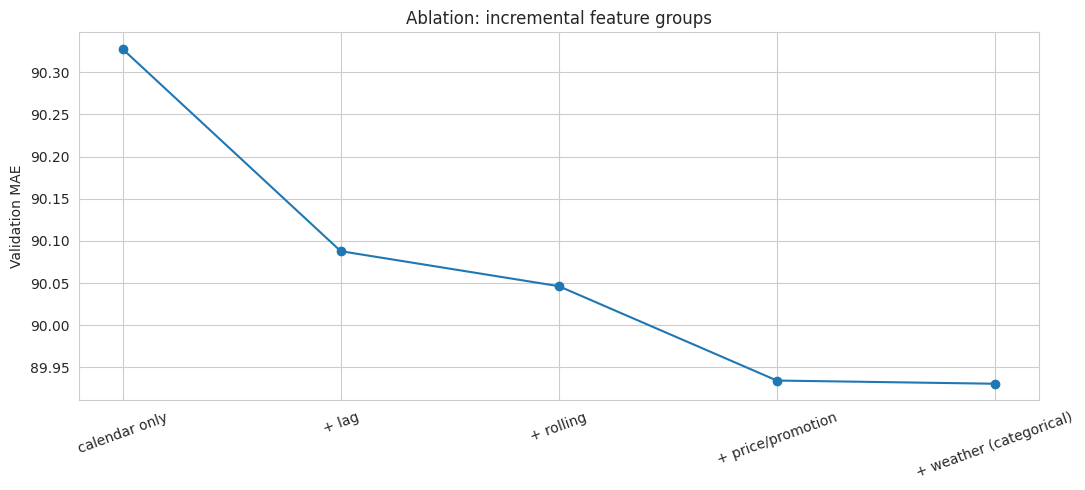

In [23]:
feature_groups = {
    "calendar only": CALENDAR_NUMERIC,
    "+ lag": CALENDAR_NUMERIC + [c for c in NUMERIC_COLS if c.startswith("lag_")],
    "+ rolling": CALENDAR_NUMERIC + [c for c in NUMERIC_COLS if c.startswith(("lag_", "rolling_"))],
}
prev = feature_groups["+ rolling"]
price_promo_cols = [c for c in RAW_NUMERIC if c not in ([COLS["inventory"]] if COLS["inventory"] else [])]
price_promo_cols += [c for c in ENGINEERED_NUMERIC if "price" in c or "discount" in c or "promotion" in c]
feature_groups["+ price/promotion"] = list(dict.fromkeys(prev + price_promo_cols))
if COLS["weather"] is not None:
    feature_groups["+ weather (categorical)"] = feature_groups["+ price/promotion"]  # weather added via NOMINAL_COLS below

ablation_rows = []
for step_name, numeric_subset in feature_groups.items():
    use_weather = "weather" in step_name
    nominal_subset = NOMINAL_COLS if use_weather else [c for c in NOMINAL_COLS if c != COLS["weather"]]

    step_preprocessor = ColumnTransformer(
        transformers=[
            ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_subset),
            ("ids", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ID_COLS),
            ("numeric", StandardScaler(), numeric_subset),
        ],
        remainder="drop",
    )
    step_cols = ID_COLS + nominal_subset + numeric_subset
    step_model = Pipeline([
        ("preprocess", step_preprocessor),
        ("model", RandomForestRegressor(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    step_model.fit(X_train[step_cols], y_train)
    pred = step_model.predict(X_val[step_cols])
    mae = mean_absolute_error(y_val, pred)
    ablation_rows.append({"step": step_name, "MAE": mae})
    print(f"{step_name:24s} MAE = {mae:.3f}")

ablation_df = pd.DataFrame(ablation_rows)
plt.figure()
plt.plot(ablation_df["step"], ablation_df["MAE"], marker="o")
plt.ylabel("Validation MAE")
plt.title("Ablation: incremental feature groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Final model: refit and evaluate once on the test set




In [24]:
search_objects = {
    "Random Forest (tuned)": rf_search,
    "XGBoost (tuned)": xgb_search,
    "LightGBM (tuned)": lgb_search,
}

best_model_name = results_df.iloc[0]["model"]
print("Selected model:", best_model_name)

if best_model_name == "Linear Regression":
    best_pipe = lr_pipe
elif best_model_name in search_objects:
    best_pipe = search_objects[best_model_name].best_estimator_
else:
    # a baseline (naive / moving average) topped validation — fall back to the best fitted model instead,
    # since the baselines have no `.fit`/`.predict` pipeline to refit on train+val
    fallback = results_df[results_df["model"].isin(list(search_objects.keys()) + ["Linear Regression"])].iloc[0]["model"]
    print(f"(Best-scoring entry was a zero-fit baseline; using the best fitted model instead: {fallback})")
    best_model_name = fallback
    best_pipe = lr_pipe if fallback == "Linear Regression" else search_objects[fallback].best_estimator_

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_model = clone(best_pipe)
final_model.fit(X_trainval, y_trainval)

test_pred = final_model.predict(X_test)
evaluate(y_test, test_pred, f"FINAL ({best_model_name}) — test set")


Selected model: Linear Regression
FINAL (Linear Regression) — test set MAE=  88.398  RMSE= 107.938  WAPE=64.788%


{'model': 'FINAL (Linear Regression) — test set',
 'MAE': 88.39799926052369,
 'RMSE': 107.93758458798996,
 'WAPE': np.float64(0.6478791569632368)}

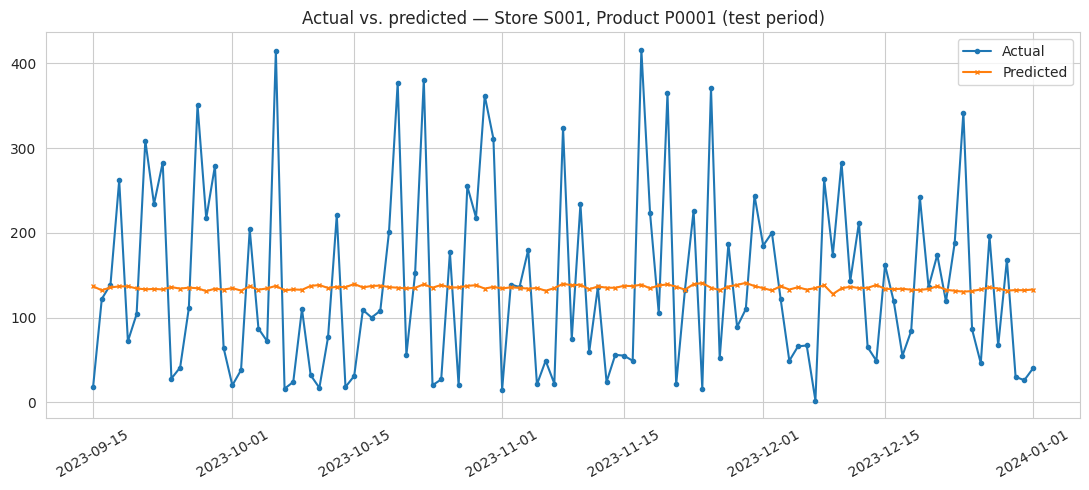

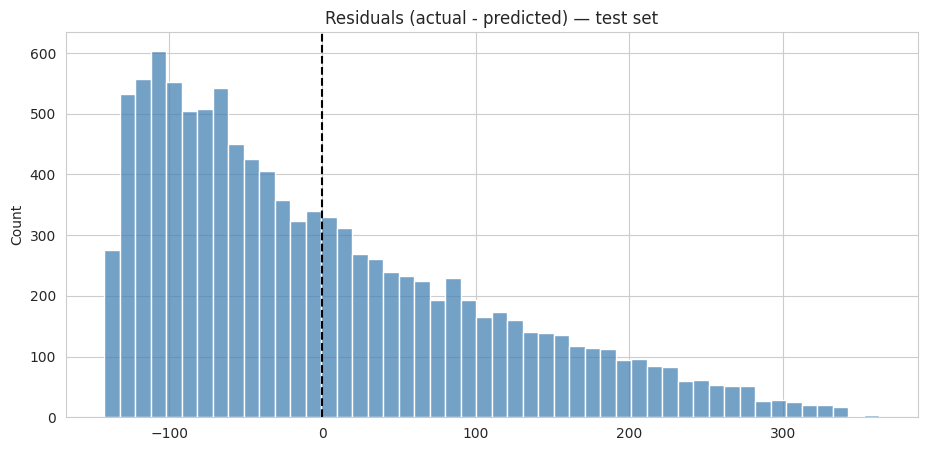

In [25]:
sample_key = feat.loc[test_mask, ID_COLS].iloc[0]
sample_mask = (feat[ID_COLS[0]] == sample_key[ID_COLS[0]]) & (feat[ID_COLS[1]] == sample_key[ID_COLS[1]])
sample_dates = feat.loc[sample_mask & test_mask, COLS["date"]]
sample_actual = feat.loc[sample_mask & test_mask, TARGET_COL]
sample_pred = final_model.predict(feat.loc[sample_mask & test_mask, FEATURE_COLS])

plt.figure()
plt.plot(sample_dates, sample_actual.values, label="Actual", marker="o", markersize=3)
plt.plot(sample_dates, sample_pred, label="Predicted", marker="x", markersize=3)
plt.title(f"Actual vs. predicted — Store {sample_key[ID_COLS[0]]}, Product {sample_key[ID_COLS[1]]} (test period)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test.values - test_pred
plt.figure()
sns.histplot(residuals, bins=50, color="steelblue")
plt.axvline(0, color="black", linestyle="--")
plt.title("Residuals (actual - predicted) — test set")
plt.show()


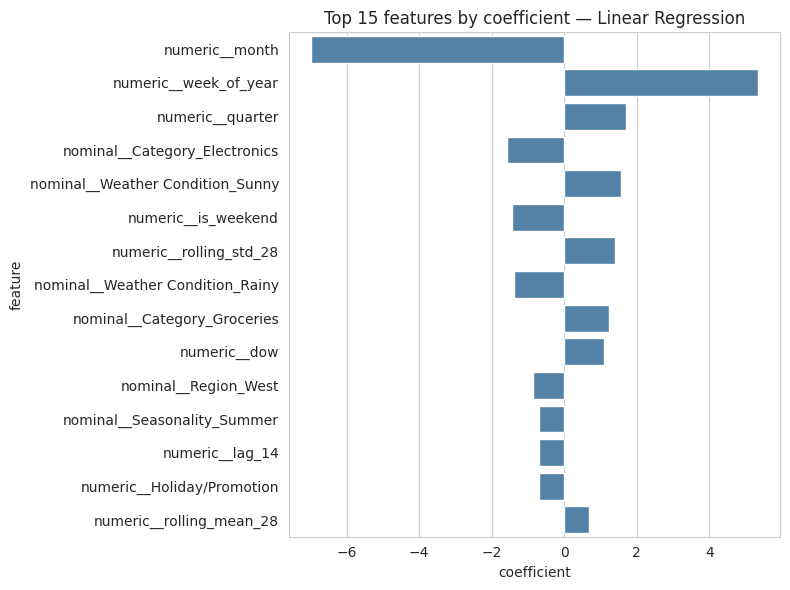

In [26]:
prep = final_model.named_steps["preprocess"]
model_step = final_model.named_steps["model"]
feature_names = prep.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    values, label = model_step.feature_importances_, "importance"
elif hasattr(model_step, "coef_"):
    values, label = model_step.coef_, "coefficient"
else:
    values, label = None, None

if values is not None:
    imp_df = pd.DataFrame({"feature": feature_names, label: values})
    imp_df = imp_df.reindex(imp_df[label].abs().sort_values(ascending=False).index).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x=label, y="feature", color="steelblue")
    plt.title(f"Top 15 features by {label} — {best_model_name}")
    plt.tight_layout()
    plt.show()


## Robustness check: rolling-origin backtesting


origin (train cutoff) evaluated through    MAE    RMSE   WAPE
           2023-02-19        2023-06-05 89.263 108.839 0.6638
           2023-04-19        2023-08-02 89.679 109.907 0.6543
           2023-06-16        2023-09-30 89.302 108.975 0.6530
           2023-08-14        2023-11-27 88.834 108.514 0.6539

MAE across origins — mean: 89.270, std: 0.346
(For reference, the single test-set MAE from Section 14 was reported above.)


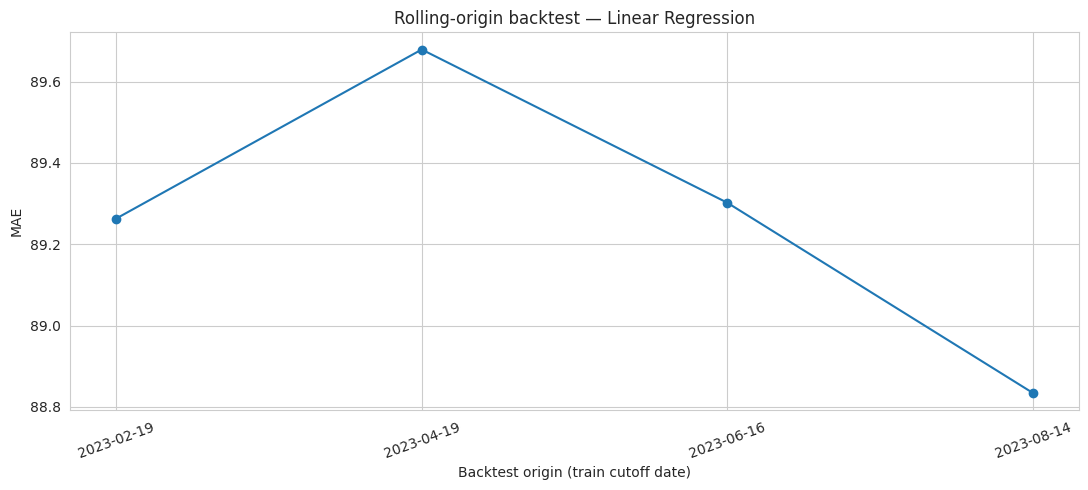

In [27]:
dates_sorted_all = np.sort(feat[COLS["date"]].unique())
n_all = len(dates_sorted_all)

N_ORIGINS = 4
EVAL_WINDOW_FRAC = 0.15  # each origin evaluates on the ~15% of dates right after its cutoff
origin_fracs = np.linspace(0.55, 0.80, N_ORIGINS)

backtest_rows = []
for frac in origin_fracs:
    origin_date = dates_sorted_all[int(n_all * frac)]
    eval_end_date = dates_sorted_all[min(int(n_all * (frac + EVAL_WINDOW_FRAC)), n_all - 1)]

    bt_train_mask = feat[COLS["date"]] <= origin_date
    bt_eval_mask = (feat[COLS["date"]] > origin_date) & (feat[COLS["date"]] <= eval_end_date)
    if bt_eval_mask.sum() == 0:
        continue

    bt_model = clone(best_pipe)
    bt_model.fit(feat.loc[bt_train_mask, FEATURE_COLS], feat.loc[bt_train_mask, TARGET_COL])
    bt_pred = bt_model.predict(feat.loc[bt_eval_mask, FEATURE_COLS])
    bt_actual = feat.loc[bt_eval_mask, TARGET_COL]

    backtest_rows.append({
        "origin (train cutoff)": pd.Timestamp(origin_date).date().isoformat(),
        "evaluated through": pd.Timestamp(eval_end_date).date().isoformat(),
        "MAE": round(mean_absolute_error(bt_actual, bt_pred), 3),
        "RMSE": round(mean_squared_error(bt_actual, bt_pred) ** 0.5, 3),
        "WAPE": round(wape(bt_actual.values, bt_pred), 4),
    })

backtest_df = pd.DataFrame(backtest_rows)
print(backtest_df.to_string(index=False))
print(f"\nMAE across origins — mean: {backtest_df['MAE'].mean():.3f}, std: {backtest_df['MAE'].std():.3f}")
print(f"(For reference, the single test-set MAE from Section 14 was reported above.)")

plt.figure()
plt.plot(backtest_df["origin (train cutoff)"], backtest_df["MAE"], marker="o")
plt.ylabel("MAE")
plt.xlabel("Backtest origin (train cutoff date)")
plt.title(f"Rolling-origin backtest — {best_model_name}")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Bonus: recursive multi-step forecast → inventory reorder recommendation

Forecasting 7 days out isn't the same as forecasting 1 day out — `lag_1` for day 2 of the horizon is
day 1's *prediction*, not a real observation, since day 1 hasn't happened yet as far as the model
knows. This does it properly: forecast day 1, feed that back in to build day 2's features, forecast
day 2, and so on. Just multiplying a single day's prediction by 7 would ignore day-of-week effects
and compound error differently.

For the inventory math, I'm assuming a fixed lead time and a 95% service level (z ≈ 1.65) applied to
the forecast's own historical error, as a stand-in for real demand uncertainty — neither of these is
in the dataset.

Worth noting: this uses `Inventory Level` directly, even though Section 8 excluded it as a same-day
model feature. Different situation — Section 8 was about not being able to know *today's* inventory
before today's sales happen. Here, `current_inventory` is just the most recent actual value on
record — the stock on the shelf right now, at decision time. That's observed, not predicted, so it's
fine.

In [28]:
LEAD_TIME_DAYS = 7
FORECAST_HORIZON_DAYS = 7
SERVICE_LEVEL_Z = 1.65  # ~95% service level under a normal-error assumption

def recursive_forecast(model, panel_row_template, history_df, horizon):
    '''Forecast `horizon` days ahead for one store-product series.

    `history_df` must contain at least `max(LAGS)` days of actual history for this series,
    sorted by date, with the same columns as `feat`.
    '''
    history = history_df.copy().reset_index(drop=True)
    last_date = history[COLS["date"]].max()
    preds = []

    for step in range(1, horizon + 1):
        next_date = last_date + pd.Timedelta(days=step)
        row = panel_row_template.copy()
        row[COLS["date"]] = next_date
        row["dow"] = next_date.dayofweek
        row["is_weekend"] = int(next_date.dayofweek in (5, 6))
        row["month"] = next_date.month
        row["quarter"] = next_date.quarter
        row["week_of_year"] = int(next_date.isocalendar().week)

        # NOTE: price/discount/promotion/weather/holiday and inventory_lag_1 are carried forward
        # from the last actual day (via `panel_row_template`, corrected once below to the right
        # value for step 1) since this bonus section has no real future plan or inventory
        # simulation to plug in. In production you'd feed in the actual planned values instead.
        target_history = pd.concat([history[TARGET_COL], pd.Series(preds)], ignore_index=True)
        for lag in LAGS:
            row[f"lag_{lag}"] = target_history.iloc[-lag] if len(target_history) >= lag else np.nan
        for window in [7, 14, 28]:
            row[f"rolling_mean_{window}"] = target_history.tail(window).mean()
        for window in [7, 28]:
            row[f"rolling_std_{window}"] = target_history.tail(window).std()

        x_row = pd.DataFrame([row])[FEATURE_COLS]
        pred = max(0.0, float(model.predict(x_row)[0]))  # demand can't be negative
        preds.append(pred)

    return preds


# Run the recursive forecast for a handful of sample store-product series
sample_series = feat[ID_COLS].drop_duplicates().sample(min(5, feat[ID_COLS].drop_duplicates().shape[0]), random_state=RANDOM_STATE)

inventory_rows = []
for _, key in sample_series.iterrows():
    mask = (feat[ID_COLS[0]] == key[ID_COLS[0]]) & (feat[ID_COLS[1]] == key[ID_COLS[1]])
    series_history = feat.loc[mask].sort_values(COLS["date"])
    if len(series_history) < max(LAGS) + 1:
        continue

    template_row = series_history.iloc[-1][FEATURE_COLS + [COLS["date"], TARGET_COL]].copy()
    if "inventory_lag_1" in template_row.index:
        # the template row's own inventory_lag_1 is two days stale by the time we forecast
        # tomorrow; correct it to today's actual inventory level before the recursive loop uses it
        template_row["inventory_lag_1"] = series_history[COLS["inventory"]].iloc[-1]
    forecast = recursive_forecast(final_model, template_row, series_history, FORECAST_HORIZON_DAYS)

    forecast_total = float(np.sum(forecast))
    # historical residual std of the 1-day-ahead model on this series, as a proxy for demand uncertainty
    hist_pred = final_model.predict(series_history[FEATURE_COLS])
    demand_std = float(np.std(series_history[TARGET_COL].values - hist_pred))

    safety_stock = SERVICE_LEVEL_Z * demand_std * np.sqrt(LEAD_TIME_DAYS)
    current_inventory = series_history[COLS["inventory"]].iloc[-1] if COLS["inventory"] else np.nan
    reorder_point = forecast_total + safety_stock
    stockout_risk = (not np.isnan(current_inventory)) and (current_inventory < reorder_point)
    recommended_order = max(0.0, reorder_point - current_inventory) if not np.isnan(current_inventory) else np.nan

    inventory_rows.append({
        "store": key[ID_COLS[0]],
        "product": key[ID_COLS[1]],
        f"forecast_next_{FORECAST_HORIZON_DAYS}d": round(forecast_total, 1),
        "safety_stock": round(safety_stock, 1),
        "current_inventory": current_inventory,
        "reorder_point": round(reorder_point, 1),
        "stockout_risk": stockout_risk,
        "recommended_order_qty": None if np.isnan(recommended_order) else round(recommended_order, 1),
    })

inventory_df = pd.DataFrame(inventory_rows)
inventory_df


/tmp/ipykernel_721/669128746.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  target_history = pd.concat([history[TARGET_COL], pd.Series(preds)], ignore_index=True)
/tmp/ipykernel_721/669128746.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  target_history = pd.concat([history[TARGET_COL], pd.Series(preds)], ignore_index=True)
/tmp/ipykernel_721/669128746.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To re

,store,product,forecast_next_7d,safety_stock,current_inventory,reorder_point,stockout_risk,recommended_order_qty
0,S005,P0004,960.1,488.0,158,1448.1,True,1290.1
1,S003,P0014,953.5,494.5,230,1448.0,True,1218.0
2,S004,P0011,977.8,465.2,155,1443.0,True,1288.0
3,S003,P0006,960.7,500.7,451,1461.3,True,1010.3
4,S003,P0005,937.1,475.2,411,1412.3,True,1001.3


**Reading this table:** `stockout_risk` flags a store-product pair whose current inventory
falls short of forecasted demand over the lead time plus a safety buffer; `recommended_order_qty` is
how much would need to be ordered now to close that gap. In a real deployment, `SERVICE_LEVEL_Z` and
`LEAD_TIME_DAYS` would come from actual supplier agreements and business risk tolerance rather than
the placeholder values used here, and the safety-stock formula's normal-error assumption is a
simplification a more rigorous version would use quantile/probabilistic forecasting instead of a
single point forecast plus an assumed error distribution.


## Key findings, limitations, and next steps

- Caught and fixed a look-ahead bug: same-day `Inventory Level` isn't actually available before
  today's sales happen, so switched to yesterday's value (Section 8).
- Engineered features (lags, rolling stats, price/promo/weather) add very little here EDA, the
  ablation study, and the rolling-origin backtest all point the same way. Likely a property of this
  particular synthetic dataset, not a general claim about retail demand.
- Linear Regression tied the tree models on validation, consistent with the above not much
  nonlinear structure for them to exploit.
- Test-set score (Section 14) is the one number that matters; everything before it is validation.

Limitations: single-timeline CV rather than per-series, placeholder lead time / service level for
the reorder math, ordinal store/product IDs won't generalize to unseen stores/products.

Next: quantile regression for real prediction intervals, hierarchical forecasting, per-series CV,
real supply-chain parameters instead of placeholders.

## Save the final model


In [29]:
import joblib

joblib.dump(final_model, "retail_demand_forecast_model.joblib")
print("Saved to retail_demand_forecast_model.joblib")


Saved to retail_demand_forecast_model.joblib
